# Readability Score Analysis Notebook
This notebook builds on the data that exists after running the code in the notebook called 'descriptive stats.ipynb'

### 1. Importing Data
Imports the csv file that was saved at the end of the descriptive_stats notebook. 

NB: If you are using an environment, please remember to choose kernel accordingly

In [21]:
# Import libraries
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import numpy as np
import nltk
from scipy.stats import levene
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
#import matplotlib.ticker as mtick
#from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
#from collections import Counter
#from wordcloud import WordCloud
from textstat import flesch_reading_ease


# Ensure stopwords are downloaded (if not already)
nltk.download('punkt')
nltk.download('stopwords')

# Import CSV file
df_all = pd.read_csv("df_desc_filt.csv", encoding="utf-8")


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/nannasteenholdt/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nannasteenholdt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_48243/576901318.py:25: DtypeWarning: Columns (132,134) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv("df_desc_filt.csv", encoding="utf-8")


### 2. Readability Score Analysis (Flesch-Kincaid)

A lower score means harder-to-read text, while a higher score means easier readability.

                count       mean        std    min    25%    50%    75%    max
Period_Group                                                                  
2022          14616.0  58.539795  11.321470 -80.78  51.58  59.09  65.76  95.37
2024/2025     10051.0  57.314318  10.592651 -50.67  50.87  57.57  64.61  95.47


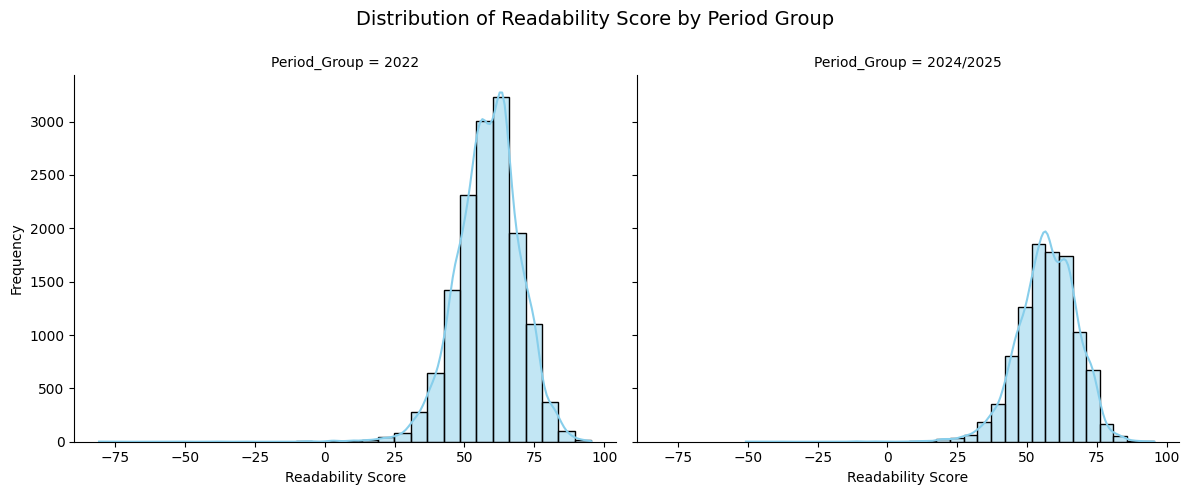

Plot saved to 'plot_outputs/readability_score_distribution_by_period_group.png'


In [22]:
# Create output directory if it doesn't exist
output_plots_dir = "plot_outputs"
os.makedirs(output_plots_dir, exist_ok=True)

# Define Danish stopwords
stop_words = set(stopwords.words('danish'))

# Convert posting date column to datetime and extract year
df_rs = df_all.copy() #Renaming df to _rs (readability score) to avoid confusion
df_rs["summary_PostingCreated"] = pd.to_datetime(df_rs["summary_PostingCreated"], errors="coerce")
df_rs["Posting_Year"] = df_rs["summary_PostingCreated"].dt.year
df_rs["Period_Group"] = df_rs["Posting_Year"].apply(
    lambda x: "2022" if x == 2022 else ("2024/2025" if x in [2024, 2025] else None)
)

# Filter out NA texts and make a copy
df_rs_grouped = df_rs[df_rs["Period_Group"].notnull()].copy()

# Compute readability score
df_rs_grouped["readability"] = df_rs_grouped["details_JobPositionPosting_JobPositionInformation_Purpose"].apply(flesch_reading_ease)

# Optional: remove extreme outliers (filter scores below -100 for sanity)
df_rs_grouped = df_rs_grouped[df_rs_grouped["readability"] > -100]

# Optional: remove extreme outliers (filter scores over 100 for sanity)
df_rs_grouped = df_rs_grouped[df_rs_grouped["readability"] < 100]

# Summary statistics
print(df_rs_grouped.groupby("Period_Group")["readability"].describe())

# Faceted histogram
g = sns.FacetGrid(
    df_rs_grouped,
    col="Period_Group",
    col_order=["2022", "2024/2025"],
    height=5,
    aspect=1.2,
    sharex=True,
    sharey=True
)
g.map(sns.histplot, "readability", bins=30, kde=True, color="skyblue")
g.set_axis_labels("Readability Score", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Distribution of Readability Score by Period Group", fontsize=14)

# Save
output_path = os.path.join(output_plots_dir, "readability_score_distribution_by_period_group.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Plot saved to '{output_path}'")

Ignore below for now:

In [23]:
# # Create output directory if it doesn't exist
# output_dir = "plot_outputs"
# os.makedirs(output_dir, exist_ok=True)

# # Define Danish stopwords
# stop_words = set(stopwords.words('danish'))

# # Convert posting date column to datetime and extract year
# df_rs = df_all.copy() #Renaming df to _rs (readability score) to avoid confusion
# df_rs["summary_PostingCreated"] = pd.to_datetime(df_rs["summary_PostingCreated"], errors="coerce")
# df_rs["Posting_Year"] = df_rs["summary_PostingCreated"].dt.year
# df_rs["Period_Group"] = df_rs["Posting_Year"].apply(
#     lambda x: "2022" if x == 2022 else ("2024/2025" if x in [2024, 2025] else None)
# )

# # Function to get most common words
# def get_most_common_words(texts, n=20):
#     words = []
#     for text in texts.dropna():
#         words.extend([word.lower() for word in word_tokenize(text) if word.isalnum() and word.lower() not in stop_words])
#     return Counter(words).most_common(n)

# # Print top words per year
# for year in df_rs["Posting_Year"].dropna().unique():
#     print(f"\nMost common words in {int(year)}:")
#     print(get_most_common_words(df_rs[df_rs["Posting_Year"] == year]["details_JobPositionPosting_JobPositionInformation_Purpose"]))

# # Create word clouds
# recent_texts = ' '.join(df_rs[df_rs["Posting_Year"] >= 2024]["details_JobPositionPosting_JobPositionInformation_Purpose"].dropna())
# older_texts = ' '.join(df_rs[df_rs["Posting_Year"] < 2024]["details_JobPositionPosting_JobPositionInformation_Purpose"].dropna())

# wordcloud_recent = WordCloud(stopwords=stop_words, background_color='white', width=800, height=400).generate(recent_texts)
# wordcloud_older = WordCloud(stopwords=stop_words, background_color='white', width=800, height=400).generate(older_texts)

# # Plot + Save recent job ads word cloud
# fig1, ax1 = plt.subplots(figsize=(10, 5))
# ax1.imshow(wordcloud_recent, interpolation='bilinear')
# ax1.axis("off")
# ax1.set_title("Word Cloud for Recent Job Ads (2024/2025)")
# fig1.tight_layout()
# recent_path = os.path.join(output_dir, "word_cloud_recent_ads_2024_2025.png")
# fig1.savefig(recent_path, dpi=300)

# # Plot + Save older job ads word cloud
# fig2, ax2 = plt.subplots(figsize=(10, 5))
# ax2.imshow(wordcloud_older, interpolation='bilinear')
# ax2.axis("off")
# ax2.set_title("Word Cloud for Older Job Ads (2022)")
# fig2.tight_layout()
# older_path = os.path.join(output_dir, "word_cloud_older_ads_2022.png")
# fig2.savefig(older_path, dpi=300)

# # Show both in notebook
# plt.show()

# print(f"Word clouds saved to:\n- {recent_path}\n- {older_path}")

# #last: 3m 31.4s

Creating series to use for statistical tests and some visualisations

In [24]:
# Create separate groups and drop NA's
group_2022 = df_rs_grouped[df_rs_grouped['Period_Group'] == '2022']['readability'].dropna()
group_2024_2025 = df_rs_grouped[df_rs_grouped['Period_Group'] == '2024/2025']['readability'].dropna()


Checks if there are any 0's.
There should not be any, so remove if there are.

In [25]:
# Check if 0's are present (there shouldn't be any)
print("Ads that have an RS of 0 in 2022:", (group_2022 == 0).sum())
print("Ads that have an RS of 0 in 2024/2025:", (group_2024_2025 == 0).sum())

# # Removes rows with 0's if present
# group_2022 = group_2022[group_2022 > 0]
# group_2024_2025 = group_2024_2025[group_2024_2025 > 0]

Ads that have an RS of 0 in 2022: 0
Ads that have an RS of 0 in 2024/2025: 0


Creating a box plot to visualise the difference between the two periods/groups.

/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_48243/1531591714.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


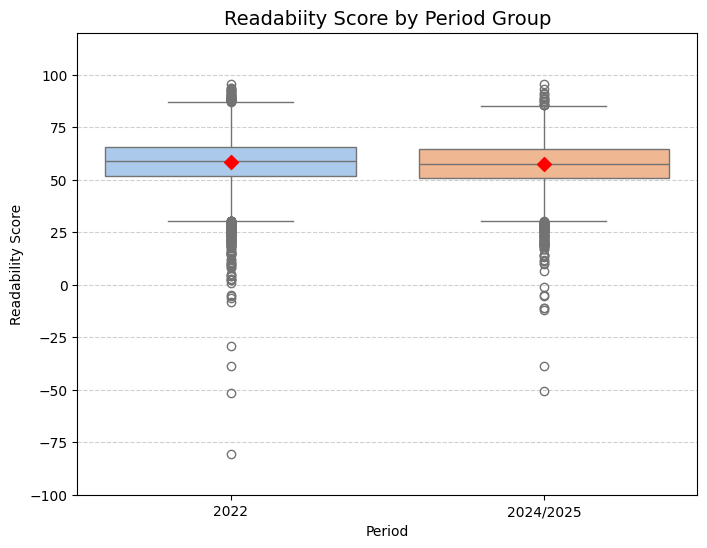

Boxplot saved to: plot_outputs/readability_score_boxplot_by_period_group.png


In [26]:
# Plot setup
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_rs_grouped,
    x='Period_Group',
    y='readability',
    order=["2022", "2024/2025"],
    palette='pastel'
)

# Add gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Overlay mean values as red diamonds
means = df_rs_grouped.groupby("Period_Group")["readability"].mean()
for i, period in enumerate(["2022", "2024/2025"]):
    plt.scatter(i, means[period], color='red', zorder=10, marker='D', s=50)

# Axis and title
plt.title("Readabiity Score by Period Group", fontsize=14)
plt.xlabel("Period")
plt.ylabel("Readability Score")
plt.ylim(-100, 120) #Adjust if needed

# Save and show
output_dir = "plot_outputs"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "readability_score_boxplot_by_period_group.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Boxplot saved to: {output_path}")


### Q-Q Plots

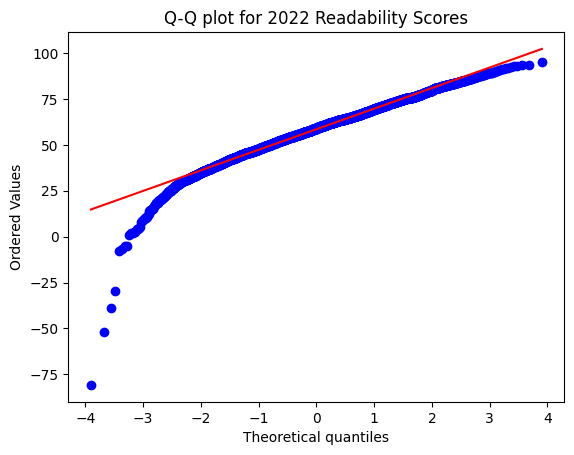

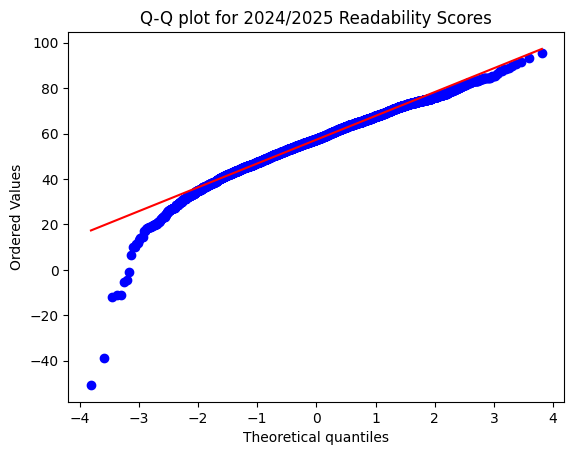

In [27]:
# For 2022
stats.probplot(group_2022, dist="norm", plot=plt)
plt.title("Q-Q plot for 2022 Readability Scores")
plt.show()

# For 2024/2025
stats.probplot(group_2024_2025, dist="norm", plot=plt)
plt.title("Q-Q plot for 2024/2025 Readability Scores")
plt.show()

Q-Q plot with *log-transformed* readability score values

/Users/nannasteenholdt/Documents/jobnet/jobnet_cleanenv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


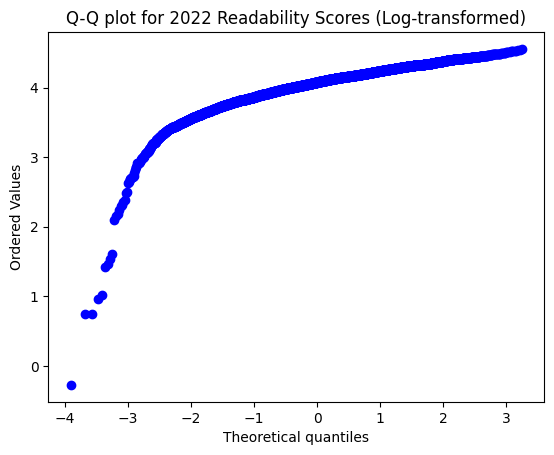

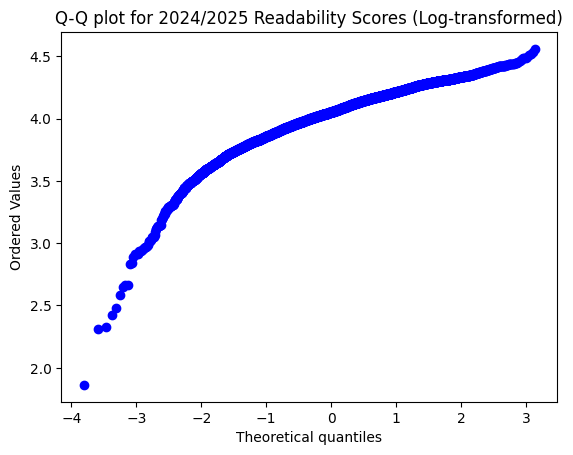

In [28]:
# For 2022
stats.probplot(np.log(group_2022), dist="norm", plot=plt)
plt.title("Q-Q plot for 2022 Readability Scores (Log-transformed)")
plt.show()

# For 2024/2025
stats.probplot(np.log(group_2024_2025), dist="norm", plot=plt)
plt.title("Q-Q plot for 2024/2025 Readability Scores (Log-transformed)")
plt.show()

### Levene's Test

Using Levene's test for checking homogeneity of variance between the two groups/periods

In [29]:
# Run Levene's test
stat, p_value = levene(group_2022, group_2024_2025)

print(f"Levene's test statistic: {stat:.3f}")
print(f"Levene's test p-value: {p_value:.6f}")

Levene's test statistic: 37.101
Levene's test p-value: 0.000000


Using Levene's test, but with *log-transformed* data

In [30]:
# Run Levene's test WITH LOG
stat, p_value = levene(np.log(group_2022), np.log(group_2024_2025))

print(f"Levene's test statistic (log): {stat:.3f}")
print(f"Levene's test p-value (log): {p_value:.6f}")

Levene's test statistic (log): nan
Levene's test p-value (log): nan


### Welsch's T-test

Using Welsch's T-test for comparing groups

In [31]:
# Welsch's T-test
statistic, p_value = ttest_ind(group_2022, group_2024_2025, equal_var=False)

print(f"Welch's t-test statistic: {statistic:.3f}")
print(f"p-value: {p_value:.6f}")

Welch's t-test statistic: 8.680
p-value: 0.000000


Running Welsch's T-test, but on log-transformed data

In [32]:
# Welsch's T-test with log transformation
statistic, p_value = ttest_ind(np.log(group_2022), np.log(group_2024_2025), equal_var=False)

print(f"Welch's t-test statistic (log): {statistic:.3f}")
print(f"p-value (log): {p_value:.6f}")

Welch's t-test statistic (log): nan
p-value (log): nan


### Cohen's D (Effect Size)

I use Cohen's D to determine the effect size

In [33]:
# Calculating means
mean_2022 = group_2022.mean()
mean_2024_2025 = group_2024_2025.mean()

# Getting standard deviations
std_2022 = group_2022.std()
std_2024_2025 = group_2024_2025.std()

# Getting sample sizes
n_2022 = len(group_2022)
n_2024_2025 = len(group_2024_2025)

# Getting the pooled standard deviation
pooled_std = np.sqrt(((n_2022 - 1) * std_2022**2 + (n_2024_2025 - 1) * std_2024_2025**2) / (n_2022 + n_2024_2025 - 2))

# Calculating Cohen's d
cohen_d = (mean_2022 - mean_2024_2025) / pooled_std

print(f"Cohen's d: {cohen_d:.3f}")

Cohen's d: 0.111


Finding Cohen's D, but with *log-transformed* data

In [34]:
# Calculating means
mean_2022 = np.log(group_2022).mean()
mean_2024_2025 = np.log(group_2024_2025).mean()

# Getting standard deviations
std_2022 = np.log(group_2022).std()
std_2024_2025 = np.log(group_2024_2025).std()

# Getting sample sizes
n_2022 = len(np.log(group_2022))
n_2024_2025 = len(np.log(group_2024_2025))

# Getting the pooled standard deviation
pooled_std = np.sqrt(((n_2022 - 1) * std_2022**2 + (n_2024_2025 - 1) * std_2024_2025**2) / (n_2022 + n_2024_2025 - 2))

# Calculating Cohen's d
cohen_d = (mean_2022 - mean_2024_2025) / pooled_std

print(f"Cohen's d (log): {cohen_d:.3f}")

Cohen's d (log): 0.085


### Robustness Check

I run a Mann-Whitney U test as a robustness check

In [35]:
# Running Mann-Whitney U test
stat, p = mannwhitneyu(group_2022, group_2024_2025, alternative='two-sided')
print(f"Mann-Whitney U p-value: {p:.6f}")

Mann-Whitney U p-value: 0.000000


Running the Mann-Whitney U with *log-transformed* values

In [36]:
# Running Mann-Whitney U test with log-transformed data
stat, p = mannwhitneyu(np.log(group_2022), np.log(group_2024_2025), alternative='two-sided')
print(f"Mann-Whitney U p-value (log): {p:.6f}")

Mann-Whitney U p-value (log): nan


Since the sample sizes were on the larger side, I make a subset of the dataset and run Welch's T-test again.

In [37]:
# Random subsample (1000 per group)
sampled_2022 = df_rs_grouped[df_rs_grouped["Period_Group"] == "2022"].sample(n=1000, random_state=42)
sampled_2024_2025 = df_rs_grouped[df_rs_grouped["Period_Group"] == "2024/2025"].sample(n=1000, random_state=42)
df_rs_grouped = pd.concat([sampled_2022, sampled_2024_2025])

# Re-run Welch's t-test
group_22 = df_rs_grouped[df_rs_grouped["Period_Group"] == "2022"]["readability"]
group_24 = df_rs_grouped[df_rs_grouped["Period_Group"] == "2024/2025"]["readability"]
print("Welch's t-test (sampled):", ttest_ind(group_22, group_24, equal_var=False).pvalue)


Welch's t-test (sampled): 0.1618322366110415
